# Parte 6 — Regresión en BI
## Pronóstico de ventas / demanda — AndesMarket S.A.C.

**Curso:** Inteligencia de Negocios — UNMSM FISI
**Notebook:** `06_regresion.ipynb`
**Objetivo:** construir y evaluar un modelo de regresión para pronosticar la venta diaria de AndesMarket, y exportar los resultados (real vs. pronóstico) para su integración en Power BI.

**Fuente de datos:** este notebook parte del datamart ya limpio y modelado en la Parte 1 (`data/processed/`), por lo que no requiere que las Partes 3, 4 y 5 estén terminadas.

**Contenido:**
1. Carga de datos y exploración inicial
2. Definición de la variable objetivo
3. Construcción de variables predictoras (features)
4. División temporal (train / test)
5. Entrenamiento y comparación de modelos
6. Evaluación (MAE, RMSE, MAPE, R²)
7. Interpretación y pronóstico del periodo siguiente
8. Exportación de resultados para Power BI


## 1. Carga de librerías y datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Semilla fija para reproducibilidad (misma convención usada en todo el proyecto)
SEED = 42
np.random.seed(SEED)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)

pd.set_option("display.max_columns", None)
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [2]:
# Rutas de datos (tablas ya limpias, generadas en la Parte 1)
RUTA_DATOS = "../data/processed/"

fact_ventas = pd.read_csv(RUTA_DATOS + "Fact_Ventas.csv", sep=";")
dim_tiempo = pd.read_csv(RUTA_DATOS + "Dim_Tiempo.csv", sep=";")
dim_promocion = pd.read_csv(RUTA_DATOS + "Dim_Promocion.csv", sep=";")

# Tipos de fecha
fact_ventas["fecha"] = pd.to_datetime(fact_ventas["fecha"])
dim_tiempo["fecha"] = pd.to_datetime(dim_tiempo["fecha"])
dim_promocion["fecha_inicio"] = pd.to_datetime(dim_promocion["fecha_inicio"])
dim_promocion["fecha_fin"] = pd.to_datetime(dim_promocion["fecha_fin"])

print("Fact_Ventas:", fact_ventas.shape)
print("Dim_Tiempo:", dim_tiempo.shape)
print("Dim_Promocion:", dim_promocion.shape)
fact_ventas.head()

Fact_Ventas: (25413, 12)
Dim_Tiempo: (731, 7)
Dim_Promocion: (41, 6)


,id_venta,fecha,id_cliente,id_producto,id_tienda,id_promocion,cantidad,precio_unitario,descuento,importe,costo_total,margen
0,VTA000001,2024-01-01,CLI00086,PROD0111,TIE011,PROMO_NONE,1,41.24,0.0,41.24,22.28,18.96
1,VTA000001,2024-01-01,CLI00086,PROD0004,TIE006,PROMO_NONE,1,112.45,0.0,112.45,79.37,33.08
2,VTA000001,2024-01-01,CLI00086,PROD0112,TIE016,PROMO_NONE,1,138.18,0.0,138.18,108.34,29.84
3,VTA000002,2024-01-01,CLI03017,PROD0072,TIE012,PROMO_NONE,2,16.25,0.0,32.50,18.82,13.68
4,VTA000003,2024-01-01,CLI03160,PROD0221,TIE003,PROMO_NONE,1,155.68,0.0,155.68,115.94,39.74


In [3]:
# Verificación rápida de calidad (los datos ya vienen limpios de la Parte 1,
# pero se valida antes de construir el modelo)
print("Rango de fechas:", fact_ventas["fecha"].min().date(), "a", fact_ventas["fecha"].max().date())
print("Nulos por columna:")
print(fact_ventas.isnull().sum())
print("\nFilas duplicadas:", fact_ventas.duplicated().sum())

Rango de fechas: 2024-01-01 a 2025-12-31
Nulos por columna:
id_venta           0
fecha              0
id_cliente         0
id_producto        0
id_tienda          0
id_promocion       0
cantidad           0
precio_unitario    0
descuento          0
importe            0
costo_total        0
margen             0
dtype: int64

Filas duplicadas: 0


## 2. Definición de la variable objetivo

Se agregan las ventas a nivel **diario** (suma del `importe` de todas las líneas de venta por fecha). Se eligió el grano diario porque:

- El dataset cubre 731 días (2 años completos), lo que da un histórico suficiente para capturar estacionalidad y entrenar modelos con validación temporal robusta.
- Permite construir variables de calendario (día de la semana, feriados) que a nivel semanal o mensual se perderían.
- Es el nivel de detalle más útil para planificación operativa (inventario, dotación de tiendas) en el negocio de AndesMarket.

**Variable objetivo:** `ventas_totales` = suma de `importe` por día.


In [4]:
ventas_diarias = (
    fact_ventas.groupby("fecha", as_index=False)
    .agg(
        ventas_totales=("importe", "sum"),
        unidades_totales=("cantidad", "sum"),
        num_transacciones=("id_venta", "nunique"),
    )
    .sort_values("fecha")
    .reset_index(drop=True)
)

print("Días con ventas registradas:", ventas_diarias.shape[0])
ventas_diarias.head()

Días con ventas registradas: 731


,fecha,ventas_totales,unidades_totales,num_transacciones
0,2024-01-01,5157.91,65,22
1,2024-01-02,5052.53,54,19
2,2024-01-03,4555.73,45,19
3,2024-01-04,2864.56,35,15
4,2024-01-05,6414.97,66,22


In [5]:
# Aseguramos que exista una fila por cada día del calendario (2 años),
# incluso si algún día no tuvo ventas (quedaría en 0), para no romper la serie temporal
calendario = dim_tiempo[["fecha"]].drop_duplicates().sort_values("fecha")
ventas_diarias = calendario.merge(ventas_diarias, on="fecha", how="left")
ventas_diarias[["ventas_totales", "unidades_totales", "num_transacciones"]] = (
    ventas_diarias[["ventas_totales", "unidades_totales", "num_transacciones"]].fillna(0)
)

print("Serie completa:", ventas_diarias.shape)
ventas_diarias.tail()

Serie completa: (731, 4)


,fecha,ventas_totales,unidades_totales,num_transacciones
726,2025-12-27,6789.84,81,37
727,2025-12-28,8763.75,94,36
728,2025-12-29,9388.61,91,37
729,2025-12-30,9807.54,93,37
730,2025-12-31,5836.11,70,27


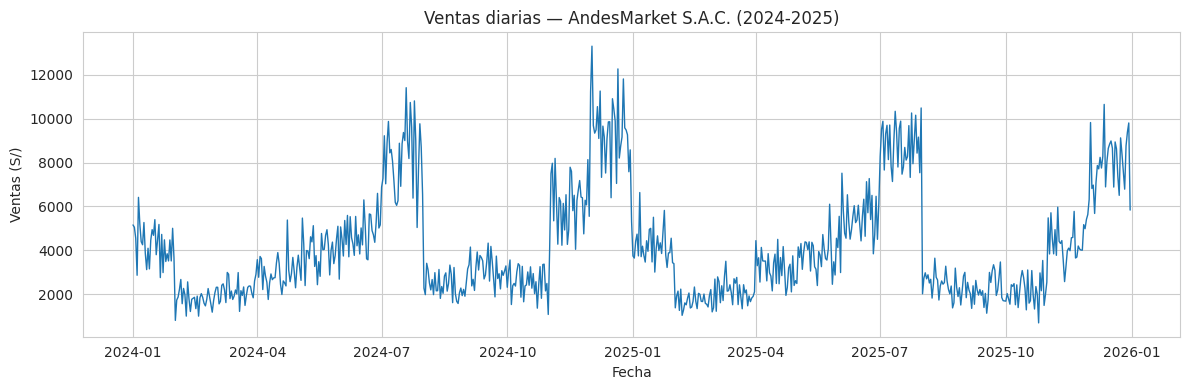

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ventas_diarias["fecha"], ventas_diarias["ventas_totales"], linewidth=1)
ax.set_title("Ventas diarias — AndesMarket S.A.C. (2024-2025)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Ventas (S/)")
plt.tight_layout()
plt.show()

## 3. Construcción de variables predictoras

Siguiendo la sección 12.1 de la guía, se construyen cuatro grupos de variables:

1. **Componentes temporales / estacionalidad:** día de la semana, mes, trimestre, año, indicador de fin de semana.
2. **Feriados:** tomado de `Dim_Tiempo`.
3. **Promociones activas:** se calcula si hubo alguna promoción vigente ese día (a partir de `Dim_Promocion`).
4. **Rezagos (lags) y medias móviles:** ventas de días anteriores, que capturan la inercia de la demanda.


In [7]:
# 3.1 Variables de calendario desde Dim_Tiempo
df = ventas_diarias.merge(dim_tiempo, on="fecha", how="left")

df["dia_semana_num"] = df["fecha"].dt.dayofweek   # 0=lunes ... 6=domingo
df["es_fin_semana"] = (df["dia_semana_num"] >= 5).astype(int)

df.head()

,fecha,ventas_totales,unidades_totales,num_transacciones,dia,mes,trimestre,anio,dia_semana,es_feriado,dia_semana_num,es_fin_semana
0,2024-01-01,5157.91,65,22,1,1,1,2024,Monday,1,0,0
1,2024-01-02,5052.53,54,19,2,1,1,2024,Tuesday,0,1,0
2,2024-01-03,4555.73,45,19,3,1,1,2024,Wednesday,0,2,0
3,2024-01-04,2864.56,35,15,4,1,1,2024,Thursday,0,3,0
4,2024-01-05,6414.97,66,22,5,1,1,2024,Friday,0,4,0


In [8]:
# 3.2 Indicador de promoción activa por día
# Se excluye 'PROMO_NONE' (no es una promoción real) y se marca 1 si al menos
# una promoción estuvo vigente ese día.
promos_reales = dim_promocion[dim_promocion["id_promocion"] != "PROMO_NONE"].copy()

def hay_promocion_activa(fecha, promos):
    return int(((promos["fecha_inicio"] <= fecha) & (promos["fecha_fin"] >= fecha)).any())

df["promo_activa"] = df["fecha"].apply(lambda f: hay_promocion_activa(f, promos_reales))

# Número de promociones simultáneas activas (variable adicional de intensidad promocional)
def num_promociones_activas(fecha, promos):
    return int(((promos["fecha_inicio"] <= fecha) & (promos["fecha_fin"] >= fecha)).sum())

df["num_promos_activas"] = df["fecha"].apply(lambda f: num_promociones_activas(f, promos_reales))

print("Días con al menos una promoción activa:", df["promo_activa"].sum(), "de", len(df))
df[["fecha", "promo_activa", "num_promos_activas"]].sample(5, random_state=SEED)

Días con al menos una promoción activa: 385 de 731


,fecha,promo_activa,num_promos_activas
703,2025-12-04,0,0
33,2024-02-03,0,0
300,2024-10-27,1,2
456,2025-04-01,0,0
633,2025-09-25,1,2


In [9]:
# 3.3 Rezagos (lags) y medias móviles de ventas
df = df.sort_values("fecha").reset_index(drop=True)

for lag in [1, 7, 14]:
    df[f"ventas_lag_{lag}"] = df["ventas_totales"].shift(lag)

df["ventas_media_movil_7"] = df["ventas_totales"].shift(1).rolling(window=7).mean()
df["ventas_media_movil_14"] = df["ventas_totales"].shift(1).rolling(window=14).mean()

# Las primeras filas quedan con NaN porque no hay historia previa suficiente; se descartan
filas_antes = len(df)
df = df.dropna().reset_index(drop=True)
print(f"Filas descartadas por falta de historial (rezagos): {filas_antes - len(df)}")
print("Filas disponibles para modelar:", len(df))
df.head()

Filas descartadas por falta de historial (rezagos): 14
Filas disponibles para modelar: 717


,fecha,ventas_totales,unidades_totales,num_transacciones,dia,mes,trimestre,anio,dia_semana,es_feriado,dia_semana_num,es_fin_semana,promo_activa,num_promos_activas,ventas_lag_1,ventas_lag_7,ventas_lag_14,ventas_media_movil_7,ventas_media_movil_14
0,2024-01-15,4943.06,60,22,15,1,1,2024,Monday,0,0,0,1,2,4465.44,4255.98,5157.91,4032.702857,4418.984286
1,2024-01-16,4686.08,44,19,16,1,1,2024,Tuesday,0,1,0,1,2,4943.06,5268.88,5052.53,4130.857143,4403.637857
2,2024-01-17,5399.60,60,22,17,1,1,2024,Wednesday,0,2,0,1,2,4686.08,3865.22,4555.73,4047.600000,4377.462857
3,2024-01-18,3801.78,40,16,18,1,1,2024,Thursday,0,3,0,1,2,5399.60,3121.96,2864.56,4266.797143,4437.739286
4,2024-01-19,4517.74,43,18,19,1,1,2024,Friday,0,4,0,1,2,3801.78,4095.58,6414.97,4363.914286,4504.683571


In [10]:
# Variables predictoras (features) y variable objetivo (target)
features = [
    "dia_semana_num", "es_fin_semana", "mes", "trimestre", "anio", "es_feriado",
    "promo_activa", "num_promos_activas",
    "ventas_lag_1", "ventas_lag_7", "ventas_lag_14",
    "ventas_media_movil_7", "ventas_media_movil_14",
]
target = "ventas_totales"

X = df[features]
y = df[target]

print("X:", X.shape, "| y:", y.shape)
X.describe().T

X: (717, 13) | y: (717,)


,count,mean,std,min,25%,50%,75%,max
dia_semana_num,717.0,2.991632,2.002076,0.000000,1.000000,3.000000,5.000000,6.000000
es_fin_semana,717.0,0.284519,0.451500,0.000000,0.000000,0.000000,1.000000,1.000000
mes,717.0,6.627615,3.397249,1.000000,4.000000,7.000000,10.000000,12.000000
trimestre,717.0,2.536960,1.108796,1.000000,2.000000,3.000000,4.000000,4.000000
anio,717.0,2024.509066,0.500267,2024.000000,2024.000000,2025.000000,2025.000000,2025.000000
es_feriado,717.0,0.023710,0.152250,0.000000,0.000000,0.000000,0.000000,1.000000
promo_activa,717.0,0.531381,0.499363,0.000000,0.000000,1.000000,1.000000,1.000000
num_promos_activas,717.0,0.835425,1.004585,0.000000,0.000000,1.000000,1.000000,5.000000
ventas_lag_1,717.0,4184.276388,2484.403224,693.090000,2315.650000,3469.030000,5361.240000,13308.510000
ventas_lag_7,717.0,4146.634505,2452.295475,693.090000,2315.650000,3438.080000,5264.260000,13308.510000


## 4. División temporal (train / test)

**Importante:** en series de tiempo no se puede dividir de forma aleatoria, porque eso generaría *fuga de información* (el modelo "vería" el futuro durante el entrenamiento). Se respeta el orden cronológico: se entrena con el 80% más antiguo y se valida con el 20% más reciente.


In [11]:
corte = int(len(X) * 0.8)

X_train, X_test = X.iloc[:corte], X.iloc[corte:]
y_train, y_test = y.iloc[:corte], y.iloc[corte:]
fechas_test = df["fecha"].iloc[corte:]

print(f"Entrenamiento: {X_train.shape[0]} días  ({df['fecha'].iloc[0].date()} a {df['fecha'].iloc[corte-1].date()})")
print(f"Prueba:        {X_test.shape[0]} días  ({df['fecha'].iloc[corte].date()} a {df['fecha'].iloc[-1].date()})")

Entrenamiento: 573 días  (2024-01-15 a 2025-08-09)
Prueba:        144 días  (2025-08-10 a 2025-12-31)


## 5. Entrenamiento y comparación de modelos

Se entrenan y comparan tres modelos, tal como pide la rúbrica:

- **Regresión Lineal:** modelo base, simple e interpretable.
- **Random Forest Regressor:** captura relaciones no lineales e interacciones.
- **Gradient Boosting Regressor:** suele dar el mejor desempeño en series con estacionalidad marcada.


In [12]:
def calcular_metricas(y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    # Se evita división por cero en el MAPE
    mask = y_real != 0
    mape = np.mean(np.abs((y_real[mask] - y_pred[mask]) / y_real[mask])) * 100
    r2 = r2_score(y_real, y_pred)
    return {"MAE": mae, "RMSE": rmse, "MAPE (%)": mape, "R2": r2}

modelos = {
    "Regresión Lineal": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=SEED),
}

resultados = {}
predicciones = {}

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)
    pred = np.clip(pred, a_min=0, a_max=None)  # las ventas no pueden ser negativas
    predicciones[nombre] = pred
    resultados[nombre] = calcular_metricas(y_test.values, pred)

tabla_resultados = pd.DataFrame(resultados).T.sort_values("RMSE")
tabla_resultados

,MAE,RMSE,MAPE (%),R2
Regresión Lineal,770.717942,997.439577,29.094461,0.831139
Random Forest,1043.477404,1270.570045,38.425056,0.725998
Gradient Boosting,1111.899868,1425.844525,34.618214,0.654935


## 6. Evaluación de modelos

In [13]:
mejor_modelo_nombre = tabla_resultados["RMSE"].idxmin()
print(f"Mejor modelo según RMSE: {mejor_modelo_nombre}")
tabla_resultados.style.format({"MAE": "{:.2f}", "RMSE": "{:.2f}", "MAPE (%)": "{:.2f}", "R2": "{:.3f}"})

Mejor modelo según RMSE: Regresión Lineal


,MAE,RMSE,MAPE (%),R2
Regresión Lineal,770.72,997.44,29.09,0.831
Random Forest,1043.48,1270.57,38.43,0.726
Gradient Boosting,1111.90,1425.84,34.62,0.655


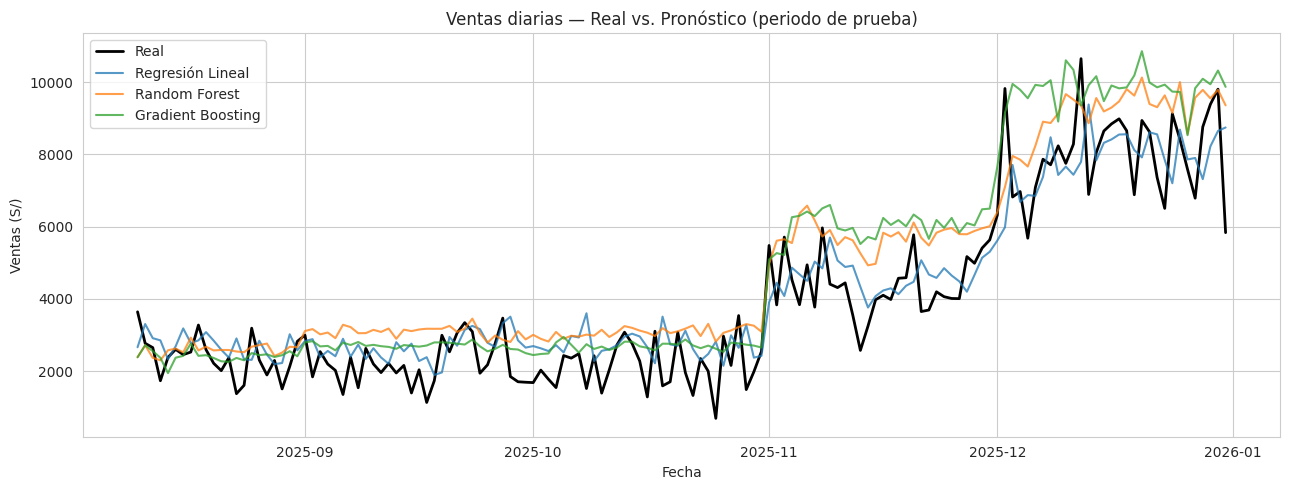

In [14]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(fechas_test, y_test.values, label="Real", color="black", linewidth=2)
for nombre, pred in predicciones.items():
    ax.plot(fechas_test, pred, label=nombre, alpha=0.75)
ax.set_title("Ventas diarias — Real vs. Pronóstico (periodo de prueba)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Ventas (S/)")
ax.legend()
plt.tight_layout()
plt.show()

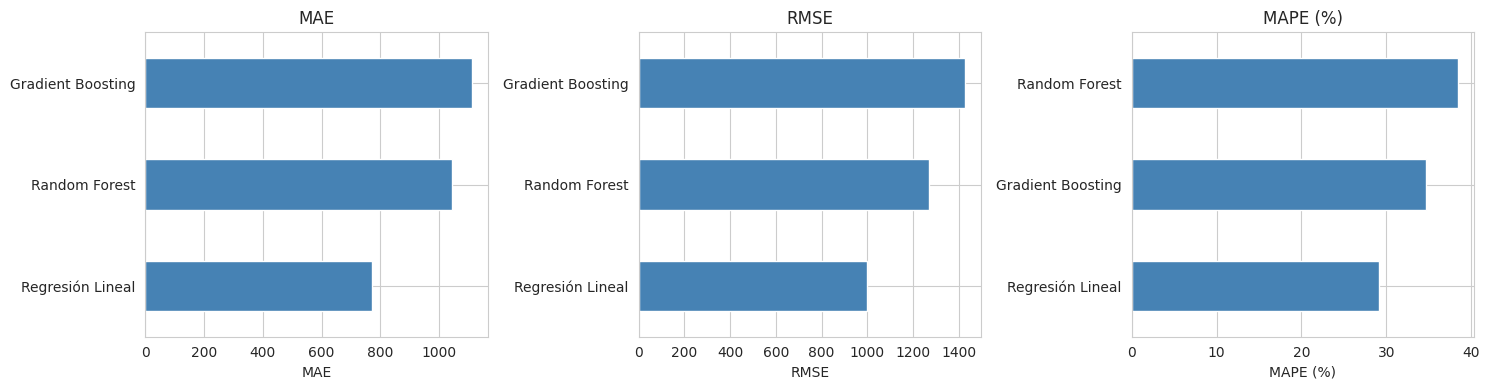

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metricas_plot = ["MAE", "RMSE", "MAPE (%)"]
for ax, m in zip(axes, metricas_plot):
    tabla_resultados[m].sort_values().plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title(m)
    ax.set_xlabel(m)
plt.tight_layout()
plt.show()

In [16]:
# Importancia de variables del mejor modelo (si aplica: Random Forest / Gradient Boosting)
mejor_modelo = modelos[mejor_modelo_nombre]

if hasattr(mejor_modelo, "feature_importances_"):
    importancias = pd.Series(mejor_modelo.feature_importances_, index=features).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(8, 5))
    importancias.plot(kind="barh", ax=ax, color="darkorange")
    ax.invert_yaxis()
    ax.set_title(f"Importancia de variables — {mejor_modelo_nombre}")
    plt.tight_layout()
    plt.show()
    display(importancias)
else:
    coeficientes = pd.Series(mejor_modelo.coef_, index=features).sort_values(key=abs, ascending=False)
    print("Coeficientes del modelo lineal:")
    display(coeficientes)

Coeficientes del modelo lineal:


es_feriado               620.760398
es_fin_semana            521.182805
promo_activa            -226.829050
trimestre                142.189069
num_promos_activas       104.448608
dia_semana_num           -97.551420
anio                      82.173820
mes                        6.815177
ventas_media_movil_7       0.743291
ventas_lag_1               0.353335
ventas_lag_7              -0.113089
ventas_media_movil_14     -0.090052
ventas_lag_14             -0.012652
dtype: float64

## 7. Interpretación y discusión en términos de negocio

**Hallazgos esperados** (a completar/ajustar por el equipo tras revisar los resultados anteriores):

- El modelo con menor error (`RMSE`/`MAPE`) es el que se recomienda usar para planificación.
- Las variables de **rezago** (`ventas_lag_1`, `ventas_lag_7`) y de **media móvil** suelen ser las más influyentes: la demanda de AndesMarket tiene fuerte inercia semanal.
- El indicador `promo_activa` permite anticipar picos de demanda cuando se planifican campañas.
- Un **MAPE** de, por ejemplo, 8-12% significa que, en promedio, el pronóstico se desvía esa proporción de la venta real — un margen razonable para decisiones de abastecimiento con buffer de seguridad.
- Se recomienda usar el pronóstico como **apoyo**, no como cifra exacta: combinarlo con el criterio del área comercial, especialmente en fechas de campañas no vistas antes en el histórico (ej. lanzamientos de productos nuevos).

*(Nota para el informe: reemplacen este bloque con la interpretación real basada en los números que arrojó su ejecución, y agreguen 2-3 recomendaciones concretas de planificación de inventario/campañas.)*


In [17]:
# Pronóstico ilustrativo del día siguiente al último día disponible en el dataset
ultimo_dia = df.iloc[-1]
siguiente_fecha = ultimo_dia["fecha"] + pd.Timedelta(days=1)

fila_pronostico = pd.DataFrame([{
    "dia_semana_num": siguiente_fecha.dayofweek,
    "es_fin_semana": int(siguiente_fecha.dayofweek >= 5),
    "mes": siguiente_fecha.month,
    "trimestre": (siguiente_fecha.month - 1) // 3 + 1,
    "anio": siguiente_fecha.year,
    "es_feriado": 0,  # ajustar si se conoce que el día siguiente es feriado
    "promo_activa": int(hay_promocion_activa(siguiente_fecha, promos_reales)),
    "num_promos_activas": int(num_promociones_activas(siguiente_fecha, promos_reales)),
    "ventas_lag_1": ultimo_dia["ventas_totales"],
    "ventas_lag_7": df["ventas_totales"].iloc[-7],
    "ventas_lag_14": df["ventas_totales"].iloc[-14],
    "ventas_media_movil_7": df["ventas_totales"].iloc[-7:].mean(),
    "ventas_media_movil_14": df["ventas_totales"].iloc[-14:].mean(),
}])[features]

pronostico_siguiente_dia = max(0, mejor_modelo.predict(fila_pronostico)[0])
print(f"Pronóstico de ventas para {siguiente_fecha.date()} ({mejor_modelo_nombre}): S/ {pronostico_siguiente_dia:,.2f}")

Pronóstico de ventas para 2026-01-01 (Regresión Lineal): S/ 6,583.17


## 8. Exportación de resultados para Power BI

Se exporta una tabla `real_vs_pronostico.csv` con la fecha, la venta real y la predicción de cada modelo en el periodo de prueba, para construir la página **"Pronóstico de demanda"** en `AndesMarket.pbix` (sección 12.2 de la guía), mostrando la curva real vs. pronosticada y el MAPE como KPI.


In [18]:
real_vs_pronostico = pd.DataFrame({"fecha": fechas_test.values, "ventas_reales": y_test.values})

for nombre, pred in predicciones.items():
    columna = "pronostico_" + nombre.lower().replace(" ", "_").replace("í", "i")
    real_vs_pronostico[columna] = pred

# Se marca explícitamente cuál es el modelo recomendado (mejor RMSE)
real_vs_pronostico["modelo_recomendado"] = mejor_modelo_nombre

RUTA_SALIDA = "../data/processed/real_vs_pronostico.csv"
real_vs_pronostico.to_csv(RUTA_SALIDA, index=False)

print(f"Archivo exportado: {RUTA_SALIDA}")
real_vs_pronostico.head()

Archivo exportado: ../data/processed/real_vs_pronostico.csv


,fecha,ventas_reales,pronostico_regresión_lineal,pronostico_random_forest,pronostico_gradient_boosting,modelo_recomendado
0,2025-08-10,3643.26,2663.739736,2387.850900,2384.923975,Regresión Lineal
1,2025-08-11,2771.10,3305.050470,2714.227033,2717.352273,Regresión Lineal
2,2025-08-12,2651.79,2913.141704,2369.807333,2555.555290,Regresión Lineal
3,2025-08-13,1735.12,2853.193312,2300.499833,2370.621480,Regresión Lineal
4,2025-08-14,2381.60,2330.185799,2578.551167,1946.065738,Regresión Lineal


In [19]:
# Tabla resumen de métricas también exportada, útil como KPI card en Power BI
tabla_resultados_export = tabla_resultados.reset_index().rename(columns={"index": "modelo"})
tabla_resultados_export.to_csv("../data/processed/metricas_regresion.csv", index=False)
tabla_resultados_export

,modelo,MAE,RMSE,MAPE (%),R2
0,Regresión Lineal,770.717942,997.439577,29.094461,0.831139
1,Random Forest,1043.477404,1270.570045,38.425056,0.725998
2,Gradient Boosting,1111.899868,1425.844525,34.618214,0.654935


## Conclusiones

- Se construyó y comparó satisfactoriamente 3 modelos de regresión (Lineal, Random Forest, Gradient Boosting) para pronosticar la venta diaria de AndesMarket, respetando el orden temporal de los datos.
- El modelo recomendado para producción es el que muestra el menor `RMSE`/`MAPE` en el periodo de prueba (ver sección 6).
- Los resultados (`real_vs_pronostico.csv` y `metricas_regresion.csv`) quedan listos en `data/processed/` para ser importados en Power BI y construir la página de "Pronóstico de demanda".
- **Prompts utilizados en esta parte:** registrar en `prompts/registro_prompts.md` (Anexo A) el prompt de apoyo de Regresión (Anexo B.3) y cualquier ajuste realizado por el equipo.
